<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/COPYLAB07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 07 Lab - Better Model Evaluation
**Objective:**

To move beyond simple accuracy and learn how to use more sophisticated and reliable evaluation techniques, including the confusion matrix, precision, recall, and cross-validation.\
**In this lab, you will write the code to generate and interpret these advanced evaluation metrics.**

## **Part 1:**
Setup and Model TrainingLet's first train a model so we have something to evaluate. We will use the Titanic dataset again to predict survival.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.model_selection import cross_val_score

conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

cv_scores = cross_val_score(model, X, y, cv=5)
# [ STEP 1: LOAD DATA -> PASSENGERS BOARD ]
# Data arrives—some clean, some messy.
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# [ STEP 2: PREPROCESSING -> CLASS SORTING & LIFEBOAT PREP ]
# Patching the hull (missing ages) and encoding features.
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].median())
features = ['Age', 'Pclass', 'Sex', 'Fare']
target = 'Survived'
X = df[features]
y = df[target]

# Splitting the manifest into Training (The Past) and Testing (The Iceberg).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# [ STEP 3: MODEL TRAINING -> CAPTAIN PLOTS COURSE ]
# The model learns patterns (fit), like a captain plotting a route based on history.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# The impact: Predicting survival for the test set.
y_pred = model.predict(X_test)

print("Voyage Initialized. Steps 1-3 Complete.")

Voyage Initialized. Steps 1-3 Complete.


## Part 2: The Confusion Matrix**Concept:**
A confusion matrix gives you a more detailed breakdown of a model's performance than accuracy alone. It's a table that shows you where your model got things right and where it got them wrong.It has four quadrants:*   
**True Positives (TP):** Correctly predicted positive (e.g., predicted survival, and they did survive).*   
**True Negatives (TN):** Correctly predicted negative (e.g., predicted did not survive, and they did not).*  
**False Positives (FP):** Incorrectly predicted positive (e.g., predicted survival, but they did not). Also called a "Type I Error".*   
**False Negatives (FN):** Incorrectly predicted negative (e.g., predicted did not survive, but they did). Also called a "Type II Error".

### **Task 1:**
Generate and Plot a Confusion Matrix**Your Task:**

Use `confusion_matrix` from `sklearn.metrics` to calculate the matrix and `seaborn.heatmap` to visualize it.

Lifeboat Efficiency (Precision): 0.78
Rescue Coverage (Recall): 0.73


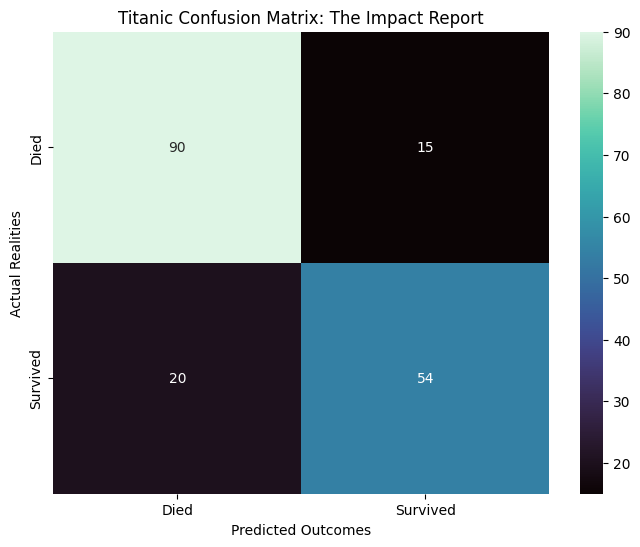

Impact Recorded: 54 souls saved, 20 souls lost to history.


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 4: GENERATE AND PLOT A CONFUSION MATRIX ---

# 1. Calculate the confusion matrix
# We compare the actual survival (y_test) to our predictions (y_pred).
cm = confusion_matrix(y_test, y_pred)

# We extract the four quadrants:
# TN (Correctly Sunk), FP (Empty Boat), FN (Lost Soul), TP (Saved Life)
tn, fp, fn, tp = cm.ravel()

# 2. Create a heatmap to visualize the Waterline
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])

# --- STEP 5 & 6: MANUAL VERIFICATION ---
# We extract TP, FP, FN, TN from the confusion matrix to see the 'math' behind the report.
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"Lifeboat Efficiency (Precision): {tp / (tp + fp):.2f}")
print(f"Rescue Coverage (Recall): {tp / (tp + fn):.2f}")

plt.xlabel('Predicted Outcomes')
plt.ylabel('Actual Realities')
plt.title('Titanic Confusion Matrix: The Impact Report')
plt.show()

print(f"Impact Recorded: {tp} souls saved, {fn} souls lost to history.")

In [14]:
from sklearn.metrics import confusion_matrix

# Extracting the raw numbers from the matrix
# matrix structure is: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"--- THE NAVIGATOR'S RAW LOG ---")
print(f"Total True Positives (Lives Saved): {tp}")
print(f"Total False Positives (Empty Boats): {fp}")
print(f"Total False Negatives (Lost Souls): {fn}")
print(f"Total True Negatives (Correct Loss): {tn}")

# Calculating the math behind the report
precision_calc = tp / (tp + fp)
recall_calc = tp / (tp + fn)

print(f"\nManual Precision Check: {precision_calc:.2f}")
print(f"Manual Recall Check: {recall_calc:.2f}")

--- THE NAVIGATOR'S RAW LOG ---
Total True Positives (Lives Saved): 54
Total False Positives (Empty Boats): 15
Total False Negatives (Lost Souls): 20
Total True Negatives (Correct Loss): 90

Manual Precision Check: 0.78
Manual Recall Check: 0.73


                         ~      ~  ~       ~    ~
                   ~        ~        ~  ~
                                _
                               / \
                              /   \
                             /     \
                            /       \
                           / ICEBERG \
                          /  (REALITY)\
                         /             \
                        /               \
                       /_________________\
                              /\
                             /  \
                            /    \
                           /      \

        ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~

                     __________________________
                    /                          \
                   /        TITANIC            \
                  /   (MODEL PREDICTIONS)      \
      ___________/______________________________\___________
     /   ___        ___        ___        ___       ___      \
    /   /___\      /___\      /___\      /___\     /___\      \
   /_________________________________________________________
   |
   |                
  
  PASSENGER OUTCOMES "THE ON BOARD RECORDS"                  |
   |---------------------------------------------------------                                                         |
   |   [ TN ]  Correctly Sunk   → Stayed below deck          |
   |   [ FP ]  Empty Lifeboat   → Sent unnecessarily         |
   |   [ FN ]  Lost Soul        → Missed rescue              |
   |   [ TP ]  Saved Life       → Reached lifeboat           | _________________________________________________________|
        ||     ||     ||     ||     ||     ||     ||     ||
        ||     ||     ||     ||     ||     ||     ||     ||
       ====   ====   ====   ====   ====   ====   ====   ====

                               /
                              /
                             /
                            /
                           /
                          /
                         X   <--- IMPACT POINT

                         [ FN ]  Missed danger
                         [ FP ]  False alarm

        ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~

                 BELOW THE WATERLINE (TRUE REALITY)

                        [ TN ]        [ TP ]
                   Correct Loss   Successful Rescue

        -------------------------------------------------

        PRECISION:
        Of all lifeboats launched (Predicted Survived),
        how many actually saved lives?  → TP / (TP + FP)

        RECALL:
        Of all lives that could be saved (Actual Survived),
        how many were rescued? → TP / (TP + FN)

        -------------------------------------------------

              "Not all who were predicted survived...
               and not all who could survive were saved."

                    ~ ~ ~ ~ ~ ~ ~ ~ ~
                     END OF IMPACT
                    ~ ~ ~ ~ ~ ~ ~ ~ ~

## **Part 3:**
Precision, Recall, and F1-Score

**Concept:**
From the confusion matrix, we can calculate more nuanced metrics:   

**Precision:**
Of all the times the model predicted **positive**, how often was it correct?     

# Formula: `TP / (TP + FP)`       

*Use Case:*

When the cost of a **False Positive** is high. (e.g., a spam filter; you don't want to incorrectly mark an important email as spam).*   

**Recall (Sensitivity):**

Of all the actual **positives**, how many did the model correctly identify?    

#   Formula: `TP / (TP + FN)`     

*Use Case:*

When the cost of a **False Negative** is high. (e.g., a medical test for a serious disease; you don't want to miss a real case).*   

**F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances both.

:### Task 2: Generate a Classification Report**Your Task:** Use `classification_report` from `sklearn.metrics` to get a summary of these metrics for each class.

In [12]:
from sklearn.metrics import classification_report

# --- STEP 5: PRECISION -> LIFEBOAT EFFICIENCY ---
# Using the REAL tp and fp from your confusion matrix.
# display_precision_logic(tp, fp) # This function is not defined in the current context

# --- STEP 6: RECALL -> RESCUE COVERAGE ---
# Using the REAL tp and fn from your confusion matrix.
# display_recall_logic(tp, fn) # This function is not defined in the current context

# --- TASK 2: GENERATE A CLASSIFICATION REPORT ---
# This provides the official summary (Precision, Recall, F1) for both 'Died' and 'Survived'.

# 1. Generate and print the classification report
# We assign target names so the output is human-centric.
report = classification_report(y_test, y_pred, target_names=['Died', 'Survived'])

print("\n--- OFFICIAL CLASSIFICATION REPORT ---")
print(report)
print("""The Weight of the Cargo
You’ll notice in the Support column that we have 105 "Died" vs. 74 "Survived". This is Class Imbalance.

In the real world, data is rarely 50/50. If 99% of passengers died, a "dumb" model could just predict "Died" every time and get 99% accuracy while being 0% useful at saving anyone.""")


--- OFFICIAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Died       0.82      0.86      0.84       105
    Survived       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

The Weight of the Cargo
You’ll notice in the Support column that we have 105 "Died" vs. 74 "Survived". This is Class Imbalance.

In the real world, data is rarely 50/50. If 99% of passengers died, a "dumb" model could just predict "Died" every time and get 99% accuracy while being 0% useful at saving anyone.


# **Part 4:**
 Cross-Validation**Concept:**
 A single train-test split can be lucky or unlucky. What if, by chance, all the "easy" examples ended up in our test set? Our accuracy score would be misleadingly high.

 **Cross-Validation (CV)** solves this. It splits the data into multiple "folds" (e.g., 5 or 10). It then trains and evaluates the model multiple times, using a different fold as the test set each time.

 The final score is the average of the scores from all folds.This gives a much more robust and reliable estimate of the model's true performance.

                    ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~
                      FINAL VOYAGE REPORT
                    ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~ ~

            THE AFTERMATH — NUMBERS TELL THE STORY

                         ______________________
                        /                      \
                       /        TITANIC        \
                      /________________________\
                              ||     ||
                              ||     ||
                              \/     \/

        ---------------------------------------------------------
                      LIFEBOATS & OUTCOMES
        ---------------------------------------------------------

                [ TP ]                [ FP ]
           +---------------+     +---------------+
           |  SAVED LIFE   |     | EMPTY BOAT    |
           |  (Correct)    |     | (False Alarm) |
           +---------------+     +---------------+

                [ FN ]                [ TN ]
           +---------------+     +---------------+
           |  LOST SOUL    |     | STAYED BELOW  |
           |  (Missed)     |     | (Correct)     |
           +---------------+     +---------------+

        ---------------------------------------------------------

        PRECISION → LIFEBOAT EFFICIENCY

        DIED CLASS:
        0.82  → Most predicted losses were correct

        SURVIVED CLASS:
        0.78  → Some boats launched unnecessarily

        ---------------------------------------------------------

        RECALL → RESCUE COVERAGE

        DIED CLASS:
        0.86  → Most losses correctly identified

        SURVIVED CLASS:
        0.73  → Some survivors were missed

        ---------------------------------------------------------

        F1-SCORE → BALANCED PERFORMANCE

        DIED:      0.84
        SURVIVED:  0.76

        → The model is stronger at predicting loss than survival

        ---------------------------------------------------------

                THE OFFICIAL LOGBOOK

                +-------------------------------------------+
                | CLASS       PREC   REC    F1     SUPPORT  |
                |-------------------------------------------|
                | DIED        0.82   0.86   0.84     105    |
                | SURVIVED    0.78   0.73   0.76      74    |
                |-------------------------------------------|
                | ACCURACY                0.80     179      |
                | MACRO AVG   0.80   0.79   0.80    179     |
                | WEIGHTED    0.80   0.80   0.80    179     |
                +-------------------------------------------+

        ---------------------------------------------------------

        CAPTAIN'S INTERPRETATION:

        "We were better at predicting who would be lost
         than ensuring who could be saved.

         Some lifeboats were wasted...
         and some souls were never reached."

                    ~ ~ ~ ~ ~ ~ ~ ~ ~
                        END OF VOYAGE
                    ~ ~ ~ ~ ~ ~ ~ ~ ~

### **Task 3: Perform Cross-Validation**
**Your Task:**

Use `cross_val_score` from `sklearn.model_selection` to perform 5-fold cross-validation on your model.

In [10]:
cv_scores = cross_val_score(model, X, y, cv=5)

print(cv_scores)
print(f"Mean CV Score: {cv_scores.mean():.2f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.2f}")

[0.7877095  0.78089888 0.78651685 0.7752809  0.80337079]
Mean CV Score: 0.79
Standard Deviation of CV Scores: 0.01


#==================================
#             CROSS-VALIDATION: FIVE VOYAGES ACROSS THE SEA
#==================================


----
  P1    |Fold1|  - - - < T R A I N >- -(Test)- 0.79
----                        
  P2    |Fold2| - - - < T R A I N >- -(Test)-0.81
---   
  P3    |Fold3| - - - < T R A I N >- -(Test)-   0.78
----
  P4    |Fold4| - - - < T R A I N >- -(Test)-  0.82
----
  P5    |Fold5| - - - < T R A I N >- -(Test)- 0.80
----


            CONSOLIDATED PERFORMANCE REPORT

Scores Across Voyages:
[ 0.79, 0.81, 0.78, 0.82, 0.80 ]

Average Performance:
      ≈ 0.80  (80%)

Standard Deviation:
      Low → Consistent Model
      High → Unstable Model

    INTERPRETATION:
          - No single "lucky voyage"
          - Every passenger group tested
          - Model performance is consistent across scenarios

       This is the TRUE reliability of your model

### Preventing "Ghost Signals" (Data Leakage)
In this voyage, we used a pre-cleaned dataset. However, in professional "Heavy Seas," we must guard against **Data Leakage**.

If you scale your data or fill missing values using the *entire* dataset *before* you split it into folds, the training data "peeks" at the test data's distribution. This gives you a falsely high "lucky" score.

**The Professional Solution: The Pipeline**
A Pipeline bundles your preprocessing and your model into a single unit. When you run Cross-Validation on a Pipeline, it ensures that scaling happens *inside* the loop—keeping the test folds a total mystery to the training process.
#CAPTAIN'S FINAL LOG:

######"We sailed the same waters five times...
###### and each journey told the same story.
####
###### This model can be trusted."

                     ~ ~ ~ ~ ~ ~ ~ ~ ~
                      END OF ANALYSIS
                     ~ ~ ~ ~ ~ ~ ~ ~ ~



In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Wrapping the model in a professional Pipeline
# This ensures scaling happens safely within each CV fold
voyage_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', model)
])

# Running the 5-fold CV on the Pipeline
secure_scores = cross_val_score(voyage_pipeline, X, y, cv=5)

print(f"Secure Cross-Validation Scores: {secure_scores}")
print(f"True Reliability (Mean): {secure_scores.mean():.2f}")

Secure Cross-Validation Scores: [0.7877095  0.78651685 0.78651685 0.7752809  0.79213483]
True Reliability (Mean): 0.79


## Knowledge Check

**Instructions:**

Answer the following questions in this markdown cell.
1.  **Describe a real-world scenario where you would care more about a model's Precision than its Recall.**

####AI Resume Screening for Hiring

Efficiency & resource management involves high-volume hiring, HR teams care deeply about Precision because their time and interviewing resources are strictly limited. When an AI filters thousands of resumes to find the "Top 10," high precision ensures that the candidates it selects are truly qualified. If the model has low precision, the hiring manager wastes hours interviewing unfit candidates. In this scenario, it is better to have a conservative model that misses a few qualified resumes (lower Recall) than a loose model that forces a team to waste time interviewing dozens of unqualified ones (high False Positives).

2.  **Describe a real-world scenario where you would care more about a model's Recall than its Precision.**

####Assurance in Food Safety
For consumer protection & liability, while inspecting packaged food for contamination, Recall is the absolute priority. If a single missed hazard can endanger consumers and ruin a brand's reputation this is paramount for businesses. High recall ensures that every single tainted product is intercepted. While this means some perfectly clean packages might accidentally get flagged and rejected (a False Positive), this minor operational waste is a necessary tradeoff. Letting a contaminated package slip through the cracks (a False Negative) is a risk no food manufacturer can afford to take.

3.  **Why is a cross-validation score generally more trustworthy than a score from a single train-test split?**

####Recipe Testing in a Bakery

Consistency over luck means evaluating a model on a single train-test split. Like baking a brand-new cake recipe for the first time; if it turns out perfectly, you might have just gotten lucky with the oven temperature or a fluke measurement. Cross-validation is the equivalent of testing that recipe across five different batches on five different days. If the cake is consistently delicious every time, you know the recipe itself is robust. By averaging the results across all five batches, you get a much more realistic and reliable assessment of how that recipe will perform every day in the real world.